# **Taller 7 - ¿Puede un mapa de calor decirle a la policía dónde patrullar?**

Presentado por:
Andrea Correa Magaña, Paula Estefania Guarin Tangarife, Juan Sebastian Calderon Guevara

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
import statsmodels.api as sm
from statsmodels.nonparametric.kernel_density import KDEMultivariate
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy import stats
import textwrap

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

# Paleta colores azules
AZUL_OSCURO = "#0D47A1"
AZUL_MEDIO  = "#1E88E5"
AZUL_CLARO  = "#90CAF9"
ACENTO      = "#E53935"
PALETA_AZUL = ["#0D47A1", "#1565C0", "#1E88E5", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB"]
CMAP_AZUL = LinearSegmentedColormap.from_list("cmap_azul", ["#BBDEFB", "#1E88E5", "#0D47A1"])

sns.set_style("white")
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETA_AZUL),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3F2FD",
    "grid.linewidth": 0.8,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

DATA_DIR = "data"
CENTRO_LON, CENTRO_LAT = -87.627800, 41.881998  # centro de la ciudad
def generar_tabla_resumen(df, titulo, cols_pct=None):

    cols_pct = cols_pct or []
    df_fmt = df.copy()
    for c in df_fmt.columns:
        if c in cols_pct:
            df_fmt[c] = df[c].apply(lambda v: f"{v:.1%}")
        elif pd.api.types.is_float_dtype(df[c]):
            df_fmt[c] = df[c].apply(lambda v: f"{v:,.4g}")

    encabezados = ["\n".join(textwrap.wrap(str(c), 16)) for c in df_fmt.columns]

    anchos_chars = []
    for c in df_fmt.columns:
        largo_dato = df_fmt[c].astype(str).str.len().max()
        largo_encabezado = max(len(linea) for linea in str(c).split())
        anchos_chars.append(max(largo_dato, largo_encabezado, 6))
    total = sum(anchos_chars)
    anchos_rel = [a / total for a in anchos_chars]

    ancho_fig = max(2.5 + 1.9 * len(df_fmt.columns), 8)
    alto_fig = 1.0 + 0.55 * len(df_fmt)

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig))
    ax.axis("off")
    tabla = ax.table(cellText=df_fmt.values, colLabels=encabezados, colWidths=anchos_rel, cellLoc="center", loc="center")
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.scale(1, 2.4)

    for (row, col), celda in tabla.get_celld().items():
        celda.set_edgecolor("white")
        celda.set_linewidth(2)
        if row == 0:
            celda.set_facecolor(AZUL_OSCURO)
            celda.get_text().set_color("white")
            celda.get_text().set_fontweight("bold")
        else:
            celda.set_facecolor("#EAF2FD" if row % 2 == 0 else "white")
        if col == 0:
            celda.set_text_props(ha="left")
            celda.PAD = 0.03

    plt.title(titulo, fontsize=14, fontweight="bold", pad=18)
    plt.tight_layout()
    plt.show()
    plt.close()

## Paso 1. Exploración de los datos y el problema de negocio

In [ ]:
crimenes = pd.read_csv(f"Chicago_delitos_verano_2019.csv", parse_dates=["fecha"])
print(crimenes.shape)
crimenes.head()

(17747, 5)


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01 05:07:00+00:00,homicidio,23,41.897950,-87.728625
1,2019-06-01 10:09:00+00:00,homicidio,71,41.753272,-87.648963
2,2019-06-01 12:46:00+00:00,homicidio,25,41.877622,-87.750728
3,2019-06-01 11:35:00+00:00,homicidio,16,41.960145,-87.699654
4,2019-06-02 09:39:00+00:00,homicidio,37,41.804773,-87.633256


In [ ]:
crimenes.info()
print()
print(crimenes["tipo_crimen"].value_counts())
print()
print("Rango de fechas:", crimenes["fecha"].min(), "a", crimenes["fecha"].max())
print("Número de áreas comunitarias con al menos un delito:", crimenes["nro_area_comunitaria"].nunique(), "de 77")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17747 entries, 0 to 17746
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   fecha                 17747 non-null  datetime64[ns, UTC]
 1   tipo_crimen           17747 non-null  object             
 2   nro_area_comunitaria  17747 non-null  int64              
 3   lat                   17747 non-null  float64            
 4   lon                   17747 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(1)
memory usage: 693.4+ KB

tipo_crimen
robo         17603
homicidio      144
Name: count, dtype: int64

Rango de fechas: 2019-06-01 05:00:00+00:00 a 2019-09-01 04:48:00+00:00
Número de áreas comunitarias con al menos un delito: 77 de 77


La base contiene 17,747 delitos registrados entre el 1 de junio y el 31 de agosto de 2019, sin ningún valor nulo en las columnas clave. Es una base muy desbalanceada por tipo de delito: 17,603 robos frente a solo 144 homicidios (menos del 1% del total), lo cual es esperable dado que los homicidios son eventos mucho más raros que los robos en cualquier ciudad. Las 77 áreas comunitarias de Chicago registran al menos un delito en el período, así que no hay zonas "vacías" que debamos excluir del análisis por falta de datos.

In [ ]:
#Cargue de los polígonos de las áreas comunitarias
areas = gpd.read_file(f"zip://Areas_comunitarias_Chicago.zip")
areas = areas[["area_numbe", "community", "geometry"]].copy()
areas["area_numbe"] = areas["area_numbe"].astype(int)

print(f"Polígonos cargados: {len(areas)}")
print(f"Sistema de coordenadas (CRS): {areas.crs}")
areas.head(3)

Polígonos cargados: 77
Sistema de coordenadas (CRS): GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


,area_numbe,community,geometry
0,35,DOUGLAS,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,36,OAKLAND,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,37,FULLER PARK,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."


El shapefile trae 77 polígonos, uno por cada área comunitaria de Chicago, en el sistema de coordenadas geográficas WGS84 (grados de latitud/longitud), que es el mismo sistema en el que vienen las coordenadas lat/lon de los delitos. Esto es importante porque significa que, por ahora, no necesitamos reproyectar nada para cruzar ambas bases. La columna area_numbe será la llave para unir esta capa geográfica con nro_area_comunitaria de la base de delitos.

In [ ]:
#Verificación de la unión entre ambas bases
ids_crimenes = set(crimenes["nro_area_comunitaria"].unique())
ids_areas = set(areas["area_numbe"].unique())

print(f"Áreas en el archivo de delitos: {len(ids_crimenes)}")
print(f"Áreas en el shapefile: {len(ids_areas)}")
print(f"Áreas en delitos que NO están en el shapefile: {ids_crimenes - ids_areas}")
print(f"Áreas del shapefile sin ningún delito registrado: {ids_areas - ids_crimenes}")

crimenes = crimenes.merge(areas[["area_numbe", "community"]],
                           left_on="nro_area_comunitaria", right_on="area_numbe", how="left")
print(f"\nDelitos sin área asignada tras la unión: {crimenes['community'].isnull().sum()}")

Áreas en el archivo de delitos: 77
Áreas en el shapefile: 77
Áreas en delitos que NO están en el shapefile: set()
Áreas del shapefile sin ningún delito registrado: set()

Delitos sin área asignada tras la unión: 0


La verificación confirma que la unión entre ambas bases es perfecta: las 77 áreas que aparecen en el archivo de delitos son exactamente las mismas 77 que trae el shapefile, sin ninguna diferencia en ambos sentidos. Al hacer el merge, ningún delito quedó sin área asignada (0 nulos), lo que significa que podemos confiar en que cada uno de los 17,747 registros de delito tiene un polígono geográfico válido asociado.

In [ ]:
#Mapa interactivo de las áreas comunitarias
mapa_areas = folium.Map(location=[CENTRO_LAT, CENTRO_LON], zoom_start=10, tiles=None)

folium.GeoJson(
    areas,
    name="Áreas comunitarias",
    style_function=lambda x: {"fillColor": AZUL_CLARO, "color": AZUL_OSCURO, "weight": 1.2, "fillOpacity": 0.5},
    tooltip=folium.GeoJsonTooltip(fields=["area_numbe", "community"], aliases=["N° área:", "Nombre:"])
).add_to(mapa_areas)

mapa_areas.fit_bounds(mapa_areas.get_bounds())
mapa_areas.save("mapa_areas_comunitarias.html")
mapa_areas

El mapa confirma visualmente que las 77 áreas comunitarias cubren toda la extensión de la ciudad de Chicago. Al pasar el cursor sobre cualquier polígono se puede leer su número y nombre.

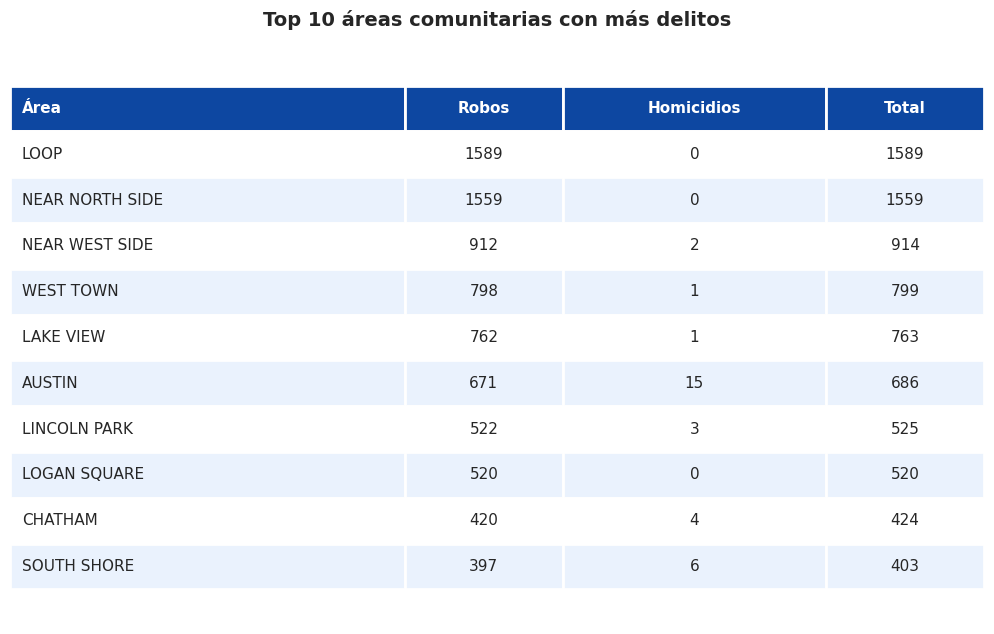

Promedio de delitos por área: 230
Mediana de delitos por área: 148
Máximo: 1589 (LOOP)
Mínimo: 12 (BURNSIDE)


In [ ]:
#Tabla descriptiva de delitos por área comunitaria
resumen_area = crimenes.pivot_table(
    index=["nro_area_comunitaria", "community"],
    columns="tipo_crimen",
    aggfunc="size",
    fill_value=0
).reset_index()
resumen_area["total_delitos"] = resumen_area["robo"] + resumen_area["homicidio"]
resumen_area = resumen_area.sort_values("total_delitos", ascending=False)

top10_tabla = resumen_area.head(10)[["community", "robo", "homicidio", "total_delitos"]]
top10_tabla.columns = ["Área", "Robos", "Homicidios", "Total"]
generar_tabla_resumen(top10_tabla, "Top 10 áreas comunitarias con más delitos")

print(f"Promedio de delitos por área: {resumen_area['total_delitos'].mean():.0f}")
print(f"Mediana de delitos por área: {resumen_area['total_delitos'].median():.0f}")
print(f"Máximo: {resumen_area['total_delitos'].max()} ({resumen_area.iloc[0]['community']})")
print(f"Mínimo: {resumen_area['total_delitos'].min()} ({resumen_area.iloc[-1]['community']})")

Existe una brecha muy amplia entre la mediana (148 delitos) y el máximo (1,589 delitos, en el Loop, el centro financiero de Chicago) de delitos por área comunitaria. El hecho de que el promedio (230) sea bastante más alto que la mediana (148) confirma que la distribución tiene "cola larga": unas pocas áreas muy delictivas empujan el promedio hacia arriba, mientras que la mayoría de las 77 áreas están por debajo de ese promedio.

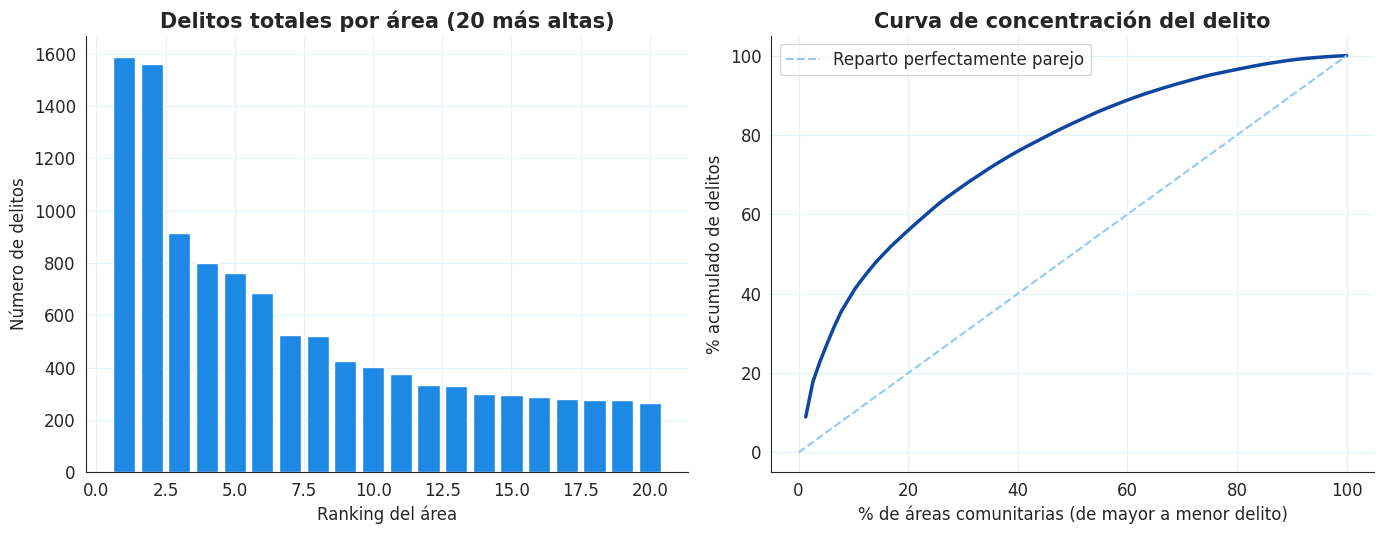

El 20% de las áreas con más delitos concentra el 55% de todos los delitos.


In [ ]:
#¿Qué tan concentrado está el delito?
resumen_ordenado = resumen_area.sort_values("total_delitos", ascending=False).reset_index(drop=True)
resumen_ordenado["pct_acumulado_delitos"] = resumen_ordenado["total_delitos"].cumsum() / resumen_ordenado["total_delitos"].sum()
resumen_ordenado["pct_acumulado_areas"] = (resumen_ordenado.index + 1) / len(resumen_ordenado)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(range(1, 21), resumen_ordenado["total_delitos"].head(20), color=AZUL_MEDIO)
axes[0].set_title("Delitos totales por área (20 más altas)")
axes[0].set_xlabel("Ranking del área")
axes[0].set_ylabel("Número de delitos")

axes[1].plot(resumen_ordenado["pct_acumulado_areas"] * 100, resumen_ordenado["pct_acumulado_delitos"] * 100,
             color=AZUL_OSCURO, linewidth=2.5)
axes[1].plot([0, 100], [0, 100], color=AZUL_CLARO, linestyle="--", label="Reparto perfectamente parejo")
axes[1].set_title("Curva de concentración del delito")
axes[1].set_xlabel("% de áreas comunitarias (de mayor a menor delito)")
axes[1].set_ylabel("% acumulado de delitos")
axes[1].legend()
plt.tight_layout()
plt.show()

pct_20 = resumen_ordenado.head(round(0.2 * len(resumen_ordenado)))["total_delitos"].sum() / resumen_ordenado["total_delitos"].sum()
print(f"El 20% de las áreas con más delitos concentra el {pct_20:.0%} de todos los delitos.")

La curva de concentración se aleja claramente de la línea de "reparto perfectamente parejo": el 20% de las áreas comunitarias (unas 15 de 77) concentra el 55% de todos los delitos del verano. En términos prácticos para la Policía, esto significa que enviar la misma cantidad de patrullas a las 77 áreas sería ineficiente, porque más de la mitad del problema está concentrado en una porción relativamente pequeña del territorio. Esta curva es exactamente el tipo de evidencia cuantitativa que sustenta, desde el inicio del análisis, la conveniencia de un protocolo de focalización frente a un patrullaje uniforme.

Top 10 áreas por ROBOS: ['AUSTIN', 'CHATHAM', 'LAKE VIEW', 'LINCOLN PARK', 'LOGAN SQUARE', 'LOOP', 'NEAR NORTH SIDE', 'NEAR WEST SIDE', 'SOUTH SHORE', 'WEST TOWN']

Top 10 áreas por HOMICIDIOS: ['AUSTIN', 'CHICAGO LAWN', 'EAST GARFIELD PARK', 'GREATER GRAND CROSSING', 'HUMBOLDT PARK', 'NORTH LAWNDALE', 'ROSELAND', 'SOUTH CHICAGO', 'SOUTH SHORE', 'WEST ENGLEWOOD']

Áreas en AMBOS top 10: ['AUSTIN', 'SOUTH SHORE'] (2 de 10)


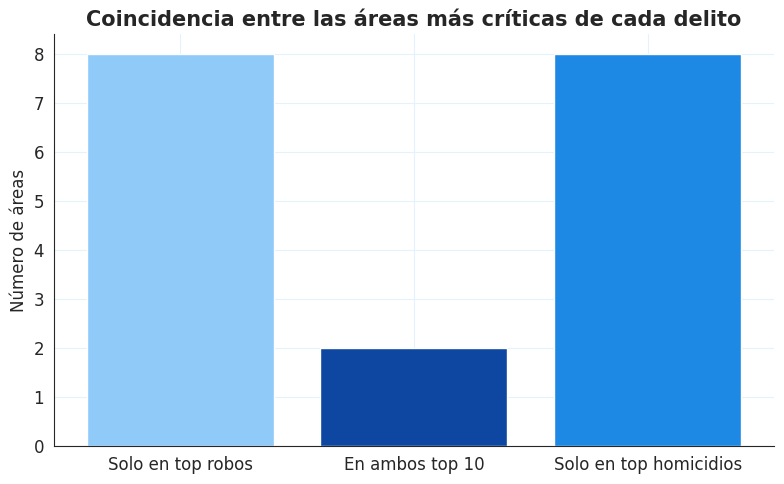

In [ ]:
#¿Coinciden las áreas con más robos y más homicidios?
top10_robos = set(resumen_area.sort_values("robo", ascending=False).head(10)["community"])
top10_homicidios = set(resumen_area.sort_values("homicidio", ascending=False).head(10)["community"])
interseccion = top10_robos & top10_homicidios

print(f"Top 10 áreas por ROBOS: {sorted(top10_robos)}")
print(f"\nTop 10 áreas por HOMICIDIOS: {sorted(top10_homicidios)}")
print(f"\nÁreas en AMBOS top 10: {sorted(interseccion)} ({len(interseccion)} de 10)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["Solo en top robos", "En ambos top 10", "Solo en top homicidios"],
       [len(top10_robos - interseccion), len(interseccion), len(top10_homicidios - interseccion)],
       color=[AZUL_CLARO, AZUL_OSCURO, AZUL_MEDIO])
ax.set_title("Coincidencia entre las áreas más críticas de cada delito")
ax.set_ylabel("Número de áreas")
plt.tight_layout()
plt.show()

Solo 2 de las 10 áreas más críticas (Austin y South Shore) coinciden entre el ranking de robos y el de homicidios. Esto revela algo importante: el Loop y Near North Side, que lideran ampliamente en robos, registran cero homicidios en todo el verano, mientras que zonas como Chicago Lawn o Roseland concentran homicidios sin aparecer entre las más afectadas por robos. Sumar ambos delitos en una sola cifra de "total de delitos" escondería esta diferencia, así que a lo largo del taller conviene mirar ambos por separado antes de emitir una recomendación conjunta.

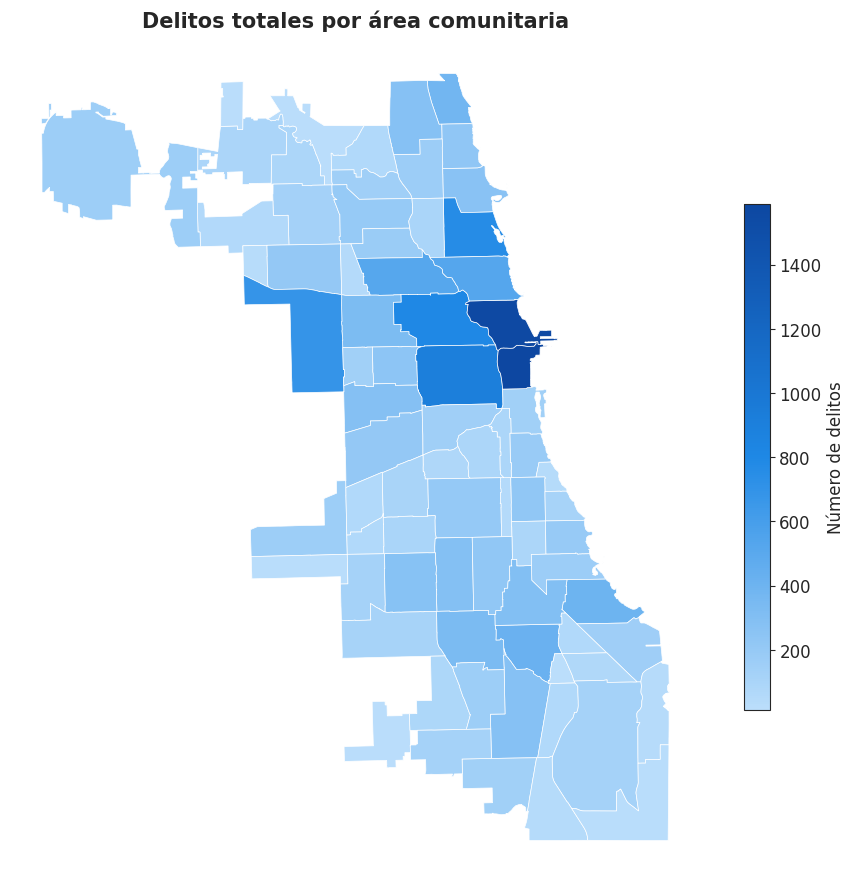

In [ ]:
#Mapa de conteo total de delitos (sin normalizar)
areas_mapa = areas.merge(resumen_area[["nro_area_comunitaria", "total_delitos", "robo", "homicidio"]],
                          left_on="area_numbe", right_on="nro_area_comunitaria", how="left")

fig, ax = plt.subplots(figsize=(9, 9))
areas_mapa.plot(column="total_delitos", cmap=CMAP_AZUL, edgecolor="white", linewidth=0.5,
                 legend=True, ax=ax, legend_kwds={"label": "Número de delitos", "shrink": 0.6})
ax.set_title("Delitos totales por área comunitaria", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

El mapa de conteo simple resalta principalmente el Loop y Near North Side, que corresponden al centro financiero y comercial de Chicago, ¿esas áreas son las más "peligrosas" o simplemente las que reciben más personas y actividad económica por metro cuadrado, y por lo tanto generan más oportunidades de robo en términos absolutos? Un conteo simple no puede responder esa pregunta por sí solo, porque no tiene en cuenta el tamaño de cada área ni su nivel de actividad.

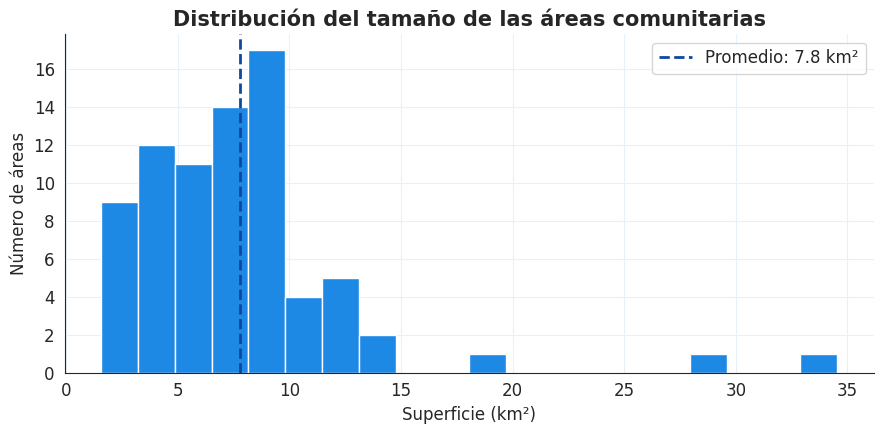

Área más pequeña: 1.57 km²
Área más grande: 34.54 km² (OHARE)
Razón entre la más grande y la más pequeña: 22x


In [ ]:
#Características espaciales
areas_proj = areas.to_crs(epsg=26971)
areas_proj["area_km2"] = areas_proj.geometry.area / 1e6

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(areas_proj["area_km2"], bins=20, color=AZUL_MEDIO, edgecolor="white")
ax.axvline(areas_proj["area_km2"].mean(), color=AZUL_OSCURO, linestyle="--", linewidth=2,
           label=f"Promedio: {areas_proj['area_km2'].mean():.1f} km²")
ax.set_title("Distribución del tamaño de las áreas comunitarias")
ax.set_xlabel("Superficie (km²)")
ax.set_ylabel("Número de áreas")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Área más pequeña: {areas_proj['area_km2'].min():.2f} km²")
print(f"Área más grande: {areas_proj['area_km2'].max():.2f} km² ({areas_proj.loc[areas_proj['area_km2'].idxmax(), 'community']})")
print(f"Razón entre la más grande y la más pequeña: {areas_proj['area_km2'].max() / areas_proj['area_km2'].min():.0f}x")

Las 77 áreas comunitarias de Chicago están lejos de tener un tamaño uniforme: la más grande (O'Hare, que incluye el aeropuerto internacional) es aproximadamente 22 veces más grande que la más pequeña. Esta diferencia de escala es una característica espacial que va a afectar directamente los procedimientos que construiremos más adelante:

## Conclusión Paso 1

La base de delitos está limpia y se une sin pérdidas con el shapefile de áreas comunitarias. El delito está claramente concentrado en el espacio (el 20% de las áreas explica el 55% del total), lo que respalda la idea de focalizar el patrullaje en lugar de distribuirlo uniformemente. Sin embargo, encontramos dos señales de alerta metodológica que condicionan todo lo que sigue: primero, robos y homicidios ocurren en geografías mayormente distintas (solo 2 de 10 áreas coinciden en ambos rankings), por lo que deben tratarse por separado antes de combinarse en una recomendación única; segundo, las áreas comunitarias varían hasta 22 veces en tamaño, así que cualquier conteo simple por área estará sesgado hacia las zonas más grandes o más transitadas, y no necesariamente hacia las más peligrosas por metro cuadrado.

## Paso 2. Correlaciones entre delitos

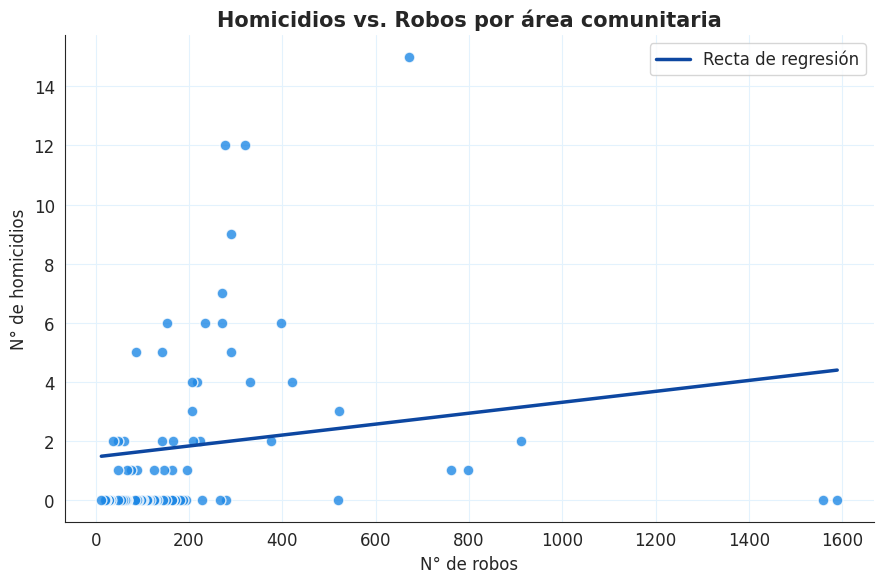

Relación estimada: homicidios ≈ 0.0019 × robos + 1.45


In [ ]:
x = resumen_area["robo"].values
y = resumen_area["homicidio"].values

pendiente, intercepto = np.polyfit(x, y, 1)
y_pred = pendiente * x + intercepto

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, color=AZUL_MEDIO, s=60, alpha=0.8, edgecolor="white")
orden = np.argsort(x)
ax.plot(x[orden], y_pred[orden], color=AZUL_OSCURO, linewidth=2.5, label="Recta de regresión")
ax.set_title("Homicidios vs. Robos por área comunitaria")
ax.set_xlabel("N° de robos")
ax.set_ylabel("N° de homicidios")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Relación estimada: homicidios ≈ {pendiente:.4f} × robos + {intercepto:.2f}")

La nube de puntos deja ver, que no hay una relación lineal fuerte entre robos y homicidios: hay áreas con muchísimos robos y cero homicidios (como el Loop), y áreas con relativamente pocos robos pero varios homicidios (como Austin). La pendiente estimada es muy pequeña (0.0019), lo que sugiere que, en promedio, hace falta un aumento enorme de robos para asociarse con apenas un homicidio adicional, una señal temprana de que ambos delitos no comparten el mismo patrón espacial.

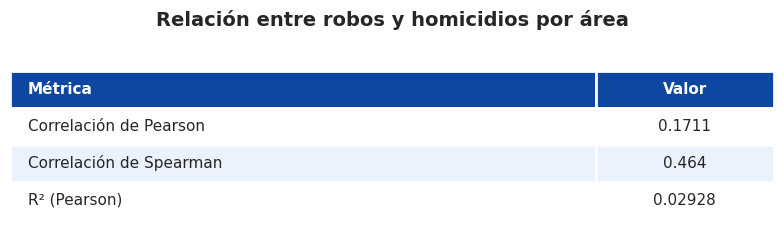

Correlación de Pearson: 0.17 (p-valor: 0.1367)
Correlación de Spearman (rangos): 0.46 (p-valor: 0.0000)
R²: solo el 3% de la variación en homicidios se explica por el n° de robos del área


In [ ]:
#Cuantificando la relación: correlación y R2
corr_pearson, p_pearson = stats.pearsonr(x, y)
corr_spearman, p_spearman = stats.spearmanr(x, y)
r_cuadrado = corr_pearson ** 2

tabla_corr = pd.DataFrame({
    "Métrica": ["Correlación de Pearson", "Correlación de Spearman", "R² (Pearson)"],
    "Valor": [corr_pearson, corr_spearman, r_cuadrado]
})
generar_tabla_resumen(tabla_corr, "Relación entre robos y homicidios por área")

print(f"Correlación de Pearson: {corr_pearson:.2f} (p-valor: {p_pearson:.4f})")
print(f"Correlación de Spearman (rangos): {corr_spearman:.2f} (p-valor: {p_spearman:.4f})")
print(f"R²: solo el {r_cuadrado:.0%} de la variación en homicidios se explica por el n° de robos del área")

La correlación de Pearson es débil y ni siquiera estadísticamente significativa (0.17, p=0.14), mientras que la correlación de Spearman es moderada y significativa (0.46, p<0.0001). Esto ocurre porque los homicidios son conteos muy pequeños y con pocos valores distintos (0, 1, 2, 3...), lo que le resta fuerza a una medida como Pearson que asume una relación lineal continua. En términos simples: existe una tendencia real de que las áreas con más robos también tiendan a tener más homicidios (por eso Spearman es significativo), pero esa relación es débil y muy ruidosa, y el R² de solo 3% confirma que casi toda la variación en homicidios se debe a otros factores que no estamos midiendo aquí.

Áreas con MÁS homicidios de lo esperado según su n° de robos:
             community  robo  homicidio  residual
                AUSTIN   671         15 12.310969
        NORTH LAWNDALE   277         12 10.040297
         HUMBOLDT PARK   319         12  9.962551
GREATER GRAND CROSSING   289          9  7.018084
              ROSELAND   270          7  5.053254

Áreas con MENOS homicidios de lo esperado según su n° de robos:
      community  robo  homicidio  residual
           LOOP  1589          0 -4.388328
NEAR NORTH SIDE  1559          0 -4.332795
   LOGAN SQUARE   520          0 -2.409517
     WEST RIDGE   280          0 -1.965256
         UPTOWN   266          0 -1.939341


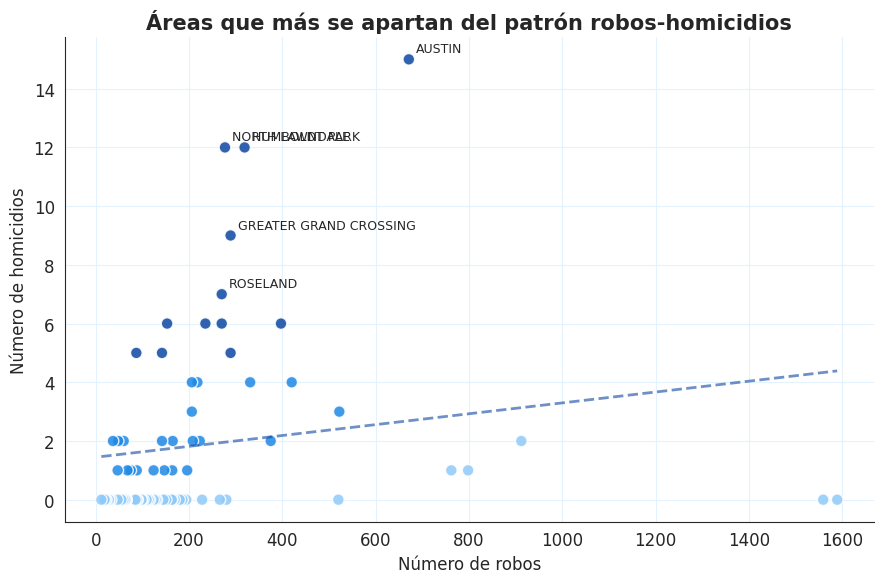

In [ ]:
#Áreas que se apartan del patrón general
resumen_area["homicidios_esperados"] = pendiente * resumen_area["robo"] + intercepto
resumen_area["residual"] = resumen_area["homicidio"] - resumen_area["homicidios_esperados"]

top_positivos = resumen_area.sort_values("residual", ascending=False).head(5)[["community", "robo", "homicidio", "residual"]]
top_negativos = resumen_area.sort_values("residual").head(5)[["community", "robo", "homicidio", "residual"]]

print("Áreas con MÁS homicidios de lo esperado según su n° de robos:")
print(top_positivos.to_string(index=False))
print("\nÁreas con MENOS homicidios de lo esperado según su n° de robos:")
print(top_negativos.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colores = np.where(resumen_area["residual"] > 3, AZUL_OSCURO,
           np.where(resumen_area["residual"] < -1, AZUL_CLARO, AZUL_MEDIO))
ax.scatter(resumen_area["robo"], resumen_area["homicidio"], color=colores, s=70, alpha=0.85, edgecolor="white")
ax.plot(x[orden], y_pred[orden], color=AZUL_OSCURO, linewidth=2, linestyle="--", alpha=0.6)
for _, fila in top_positivos.iterrows():
    ax.annotate(fila["community"], (fila["robo"], fila["homicidio"]), fontsize=9,
                xytext=(5, 5), textcoords="offset points")
ax.set_title("Áreas que más se apartan del patrón robos-homicidios")
ax.set_xlabel("Número de robos")
ax.set_ylabel("Número de homicidios")
plt.tight_layout()
plt.show()

Las áreas que más homicidios tienen de lo que "predicen" sus robos son Austin, North Lawndale, Humboldt Park, Greater Grand Crossing y Roseland, todas zonas del oeste y sur de Chicago. En el extremo opuesto, el Loop y Near North Side tienen muchísimos robos pero cero homicidios, muy por debajo de lo esperado. Este patrón no es casualidad estadística menor: son las mismas áreas que ya habíamos visto en el Paso 1 liderando cada ranking por separado, lo que refuerza la idea de que Chicago tiene, en la práctica, dos geografías del delito distintas y parcialmente independientes.

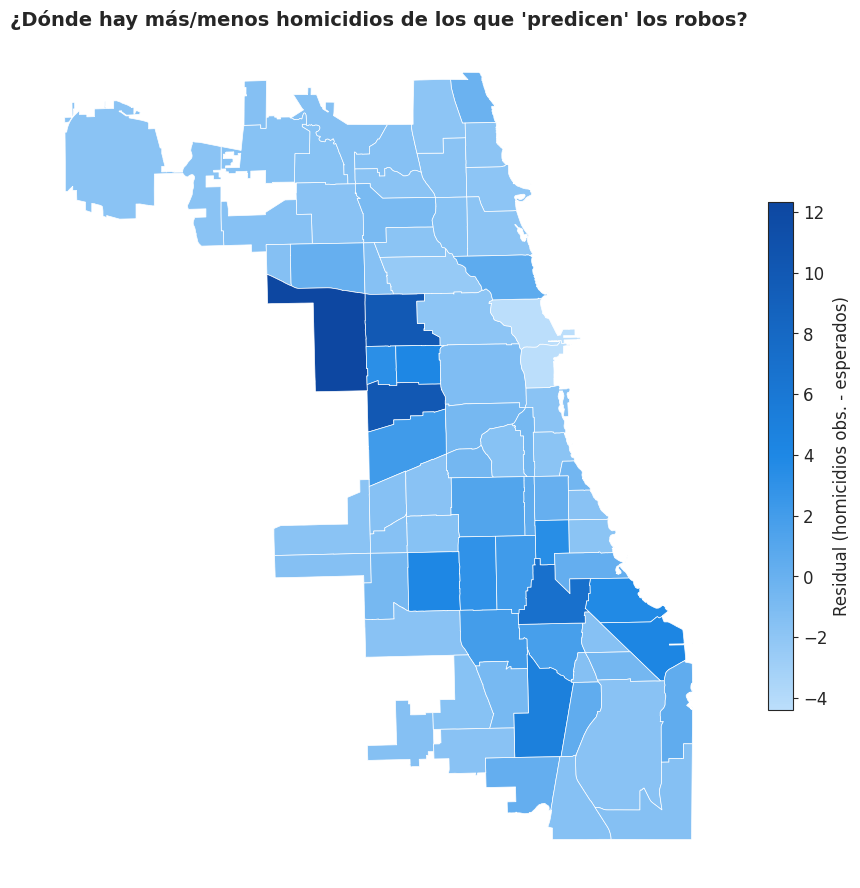

In [ ]:
#Ubicación de las áreas atípicas en el mapa
areas_residual = areas.merge(resumen_area[["nro_area_comunitaria", "residual"]],
                              left_on="area_numbe", right_on="nro_area_comunitaria", how="left")

fig, ax = plt.subplots(figsize=(9, 9))
areas_residual.plot(column="residual", cmap=CMAP_AZUL, edgecolor="white", linewidth=0.5,
                     legend=True, ax=ax, legend_kwds={"label": "Residual (homicidios obs. - esperados)", "shrink": 0.6})
ax.set_title("¿Dónde hay más/menos homicidios de los que 'predicen' los robos?", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

al llevar las áreas atípicas al mapa, se confirma que no están dispersos al azar por la ciudad, sino agrupados espacialmente: las áreas con más homicidios de lo esperado forman un bloque contiguo en el oeste y sur de Chicago, mientras que las de menos homicidios de lo esperado se concentran en el norte y el centro. Que el patrón forme bloques geográficos, y no un mosaico aleatorio, es una señal de que hay factores estructurales de fondo (posiblemente socioeconómicos) que afectan de forma distinta a cada tipo de delito, y no un simple efecto del azar.

In [ ]:
#¿Qué tan sólida es la evidencia para cada tipo de delito?
np.random.seed(RANDOM_STATE)
tasa_homicidios = resumen_area["homicidio"].mean()
simulacion_homicidios = np.random.poisson(tasa_homicidios, size=(1000, len(resumen_area)))
cv_simulado = simulacion_homicidios.std(axis=1) / simulacion_homicidios.mean(axis=1)
cv_observado_homicidios = resumen_area["homicidio"].std() / resumen_area["homicidio"].mean()
cv_observado_robos = resumen_area["robo"].std() / resumen_area["robo"].mean()

print(f"Promedio de homicidios por área: {tasa_homicidios:.2f} (muy pocos casos por área)")
print(f"Coeficiente de variación OBSERVADO en homicidios: {cv_observado_homicidios:.2f}")
print(f"Coeficiente de variación esperado SOLO POR AZAR (simulación Poisson): {cv_simulado.mean():.2f}")
print(f"Coeficiente de variación OBSERVADO en robos: {cv_observado_robos:.2f}")

Promedio de homicidios por área: 1.87 (muy pocos casos por área)
Coeficiente de variación OBSERVADO en homicidios: 1.65
Coeficiente de variación esperado SOLO POR AZAR (simulación Poisson): 0.73
Coeficiente de variación OBSERVADO en robos: 1.25


Con un promedio de apenas 1.87 homicidios por área en todo el verano, cada área es esencialmente un conteo de "pocos eventos raros", lo cual hace que cualquier ranking basado en homicidios sea estadísticamente más frágil que uno basado en robos. Para probarlo, simulamos qué tan dispersos se verían los homicidios si solo dependieran del azar (un proceso puramente aleatorio con la misma tasa promedio): esa dispersión simulada (0.73) es bastante menor que la observada en los datos reales (1.65).

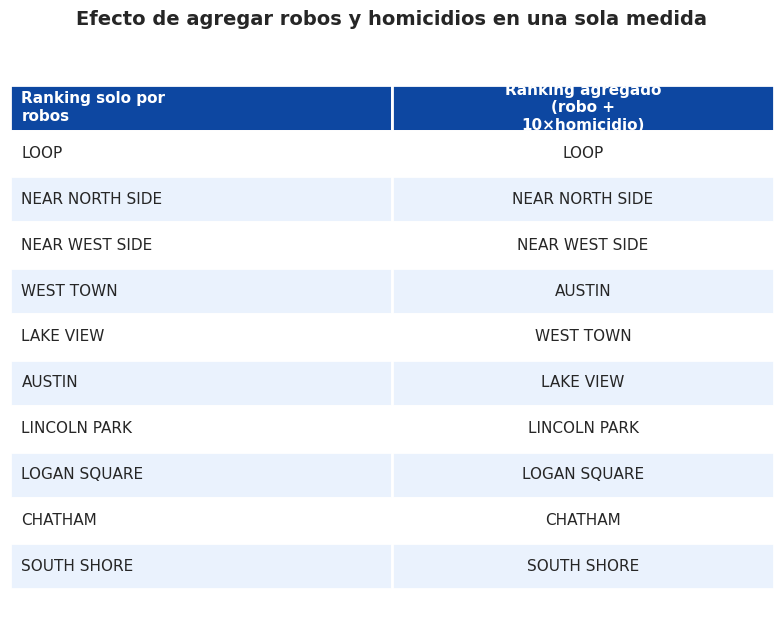

In [ ]:
#¿Qué implicaría agregar ambos delitos en una sola medida?
resumen_area["delito_agregado"] = resumen_area["robo"] + resumen_area["homicidio"] * 10  # ponderación de ejemplo

ranking_agregado = resumen_area.sort_values("delito_agregado", ascending=False).head(10)["community"].tolist()
ranking_solo_robos = resumen_area.sort_values("robo", ascending=False).head(10)["community"].tolist()

tabla_agregacion = pd.DataFrame({
    "Ranking solo por robos": ranking_solo_robos,
    "Ranking agregado (robo + 10×homicidio)": ranking_agregado
})
generar_tabla_resumen(tabla_agregacion, "Efecto de agregar robos y homicidios en una sola medida")

incluso usando una ponderación arbitraria que le da 10 veces más peso a cada homicidio que a cada robo, el ranking de las 10 áreas más críticas cambia relativamente poco (Austin sube del puesto 6 al 4, el resto se mantiene casi igual). Esto es porque los robos son tan numerosos frente a los homicidios (17,603 contra 144) que dominan cualquier medida agregada, sin importar mucho la ponderación que se use, salvo que esta sea extrema.

## Conclusión Paso 2

La relación entre robos y homicidios por área es débil y estadísticamente frágil bajo una medida lineal (Pearson no significativo), aunque existe una asociación de rangos moderada y significativa (Spearman). Los residuales de la regresión muestran un patrón espacial claro y no aleatorio: un bloque de áreas en el oeste/sur con más homicidios de los esperados, y el centro/norte con menos. La evidencia para homicidios es menos sólida que para robos, por el bajo número de casos (aunque la simulación confirma que hay señal real más allá del ruido). Finalmente, agregar ambos delitos en una sola medida es riesgoso: los robos, por su volumen, dominarían cualquier ranking combinado y podrían esconder zonas de alta letalidad con relativamente pocos robos; un argumento fuerte para tratar ambos delitos por separado en los procedimientos de focalización que construiremos en los siguientes pasos.

## Paso 3. Visualizando los datos

In [ ]:
#Sistema de coordenadas métrico y cálculo de superficies
areas_proj = areas.to_crs(epsg=26971)
areas_proj["area_km2"] = areas_proj.geometry.area / 1e6

resumen_area = resumen_area.merge(areas_proj[["area_numbe", "area_km2"]],
                                   left_on="nro_area_comunitaria", right_on="area_numbe", how="left")

print(f"CRS usado: EPSG:26971 (NAD83 / Illinois East), unidades en metros")
print(f"Superficie total de Chicago (suma de las 77 áreas): {resumen_area['area_km2'].sum():.0f} km²")
print(resumen_area[["community", "area_km2"]].sort_values("area_km2", ascending=False).head(3).to_string(index=False))

CRS usado: EPSG:26971 (NAD83 / Illinois East), unidades en metros
Superficie total de Chicago (suma de las 77 áreas): 598 km²
    community  area_km2
        OHARE 34.544797
SOUTH DEERING 28.223783
       AUSTIN 18.511395


elegimos EPSG:26971 porque es el sistema de coordenadas proyectado estándar para la zona de Illinois, con unidades en metros, lo que permite calcular áreas correctamente. La superficie total de las 77 áreas comunitarias suma 598 km2, y confirmamos que O'Hare (el área con el aeropuerto) es la más extensa, seguida de South Deering y Austin. Esta base de superficies es el insumo que nos falta para pasar del conteo simple a un conteo normalizado

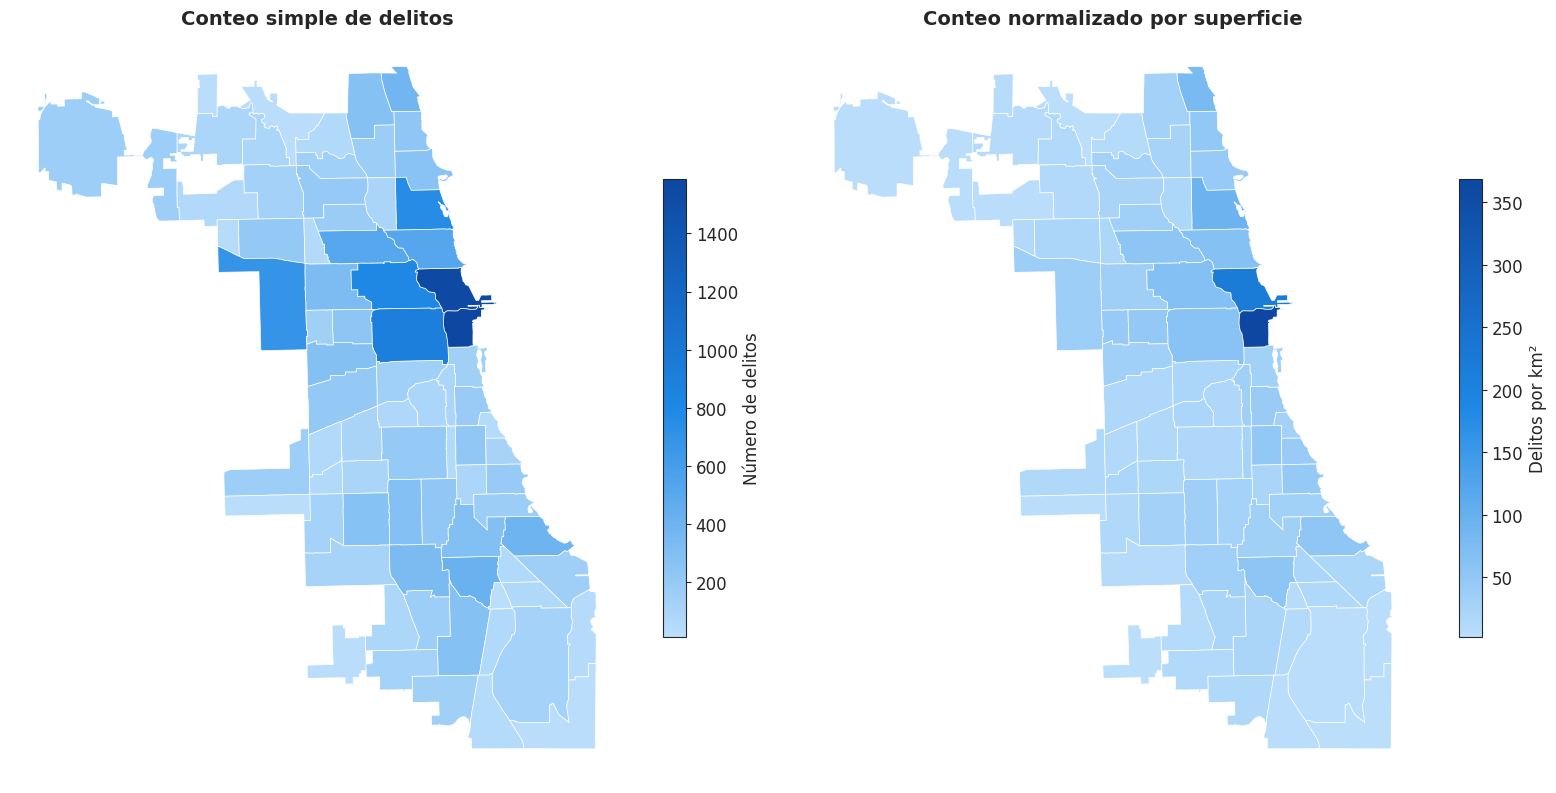

Top 5 por CONTEO simple:
      community  total_delitos
           LOOP           1589
NEAR NORTH SIDE           1559
 NEAR WEST SIDE            914
      WEST TOWN            799
      LAKE VIEW            763

Top 5 por DENSIDAD (delitos/km²):
      community  delitos_por_km2
           LOOP            369.1
NEAR NORTH SIDE            218.9
      LAKE VIEW             94.2
    ROGERS PARK             79.2
      WEST TOWN             67.4


In [ ]:
#Mapa de conteo simple vs. mapa normalizado por superficie
resumen_area["delitos_por_km2"] = resumen_area["total_delitos"] / resumen_area["area_km2"]

areas_mapa = areas.merge(
    resumen_area[["nro_area_comunitaria", "total_delitos", "delitos_por_km2"]],
    left_on="area_numbe", right_on="nro_area_comunitaria", how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

areas_mapa.plot(column="total_delitos", cmap=CMAP_AZUL, edgecolor="white", linewidth=0.5,
                 legend=True, ax=axes[0], legend_kwds={"label": "Número de delitos", "shrink": 0.6})
axes[0].set_title("Conteo simple de delitos", fontsize=14, fontweight="bold")
axes[0].axis("off")

areas_mapa.plot(column="delitos_por_km2", cmap=CMAP_AZUL, edgecolor="white", linewidth=0.5,
                 legend=True, ax=axes[1], legend_kwds={"label": "Delitos por km²", "shrink": 0.6})
axes[1].set_title("Conteo normalizado por superficie", fontsize=14, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Top 5 por CONTEO simple:")
print(resumen_area.sort_values("total_delitos", ascending=False).head(5)[["community", "total_delitos"]].to_string(index=False))
print("\nTop 5 por DENSIDAD (delitos/km²):")
print(resumen_area.sort_values("delitos_por_km2", ascending=False).head(5)[["community", "delitos_por_km2"]].round(1).to_string(index=False))

Al normalizar por superficie, Near West Side sale del top 5, y en su lugar aparece Rogers Park, un área pequeña en el extremo norte de la ciudad que por conteo simple no destacaba tanto pero que, al ser compacta, tiene una densidad de delitos relativamente alta. Visualmente, el mapa de densidad también resalta con más fuerza el contraste entre el Loop (muy pequeño y muy denso: 369 delitos/km²) y áreas grandes como O'Hare, que en el mapa de conteo simple no se ven tan intensas pero que en densidad prácticamente desaparecen del radar.

Áreas en el top 10 por CONTEO pero no por DENSIDAD: ['AUSTIN']
Áreas en el top 10 por DENSIDAD pero no por CONTEO: ['ROGERS PARK']
Coincidencias en ambos top 10: 9 de 10

Correlación de Spearman entre ambos rankings (las 77 áreas): 0.80


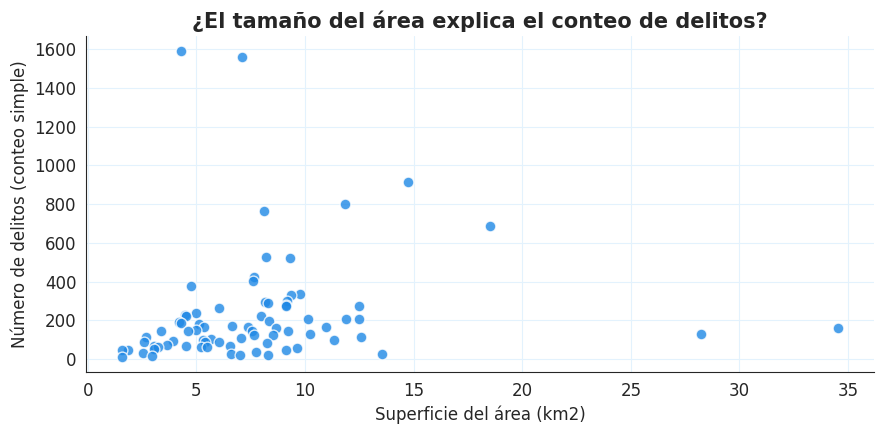

Correlación entre superficie y conteo simple de delitos: 0.13


In [ ]:
#¿Cuánto cambia el ranking al normalizar por superficie?
top10_conteo = set(resumen_area.sort_values("total_delitos", ascending=False).head(10)["community"])
top10_densidad = set(resumen_area.sort_values("delitos_por_km2", ascending=False).head(10)["community"])

corr_rankings, _ = stats.spearmanr(resumen_area["total_delitos"], resumen_area["delitos_por_km2"])

print(f"Áreas en el top 10 por CONTEO pero no por DENSIDAD: {sorted(top10_conteo - top10_densidad)}")
print(f"Áreas en el top 10 por DENSIDAD pero no por CONTEO: {sorted(top10_densidad - top10_conteo)}")
print(f"Coincidencias en ambos top 10: {len(top10_conteo & top10_densidad)} de 10")
print(f"\nCorrelación de Spearman entre ambos rankings (las 77 áreas): {corr_rankings:.2f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(resumen_area["area_km2"], resumen_area["total_delitos"], color=AZUL_MEDIO, s=60, alpha=0.8, edgecolor="white")
ax.set_title("¿El tamaño del área explica el conteo de delitos?")
ax.set_xlabel("Superficie del área (km2)")
ax.set_ylabel("Número de delitos (conteo simple)")
plt.tight_layout()
plt.show()

corr_tamano, _ = stats.pearsonr(resumen_area["area_km2"], resumen_area["total_delitos"])
print(f"Correlación entre superficie y conteo simple de delitos: {corr_tamano:.2f}")

El impacto de normalizar es real pero moderado a nivel general: 9 de las 10 áreas más críticas coinciden en ambos rankings (solo Austin sale y Rogers Park entra), y la correlación de Spearman entre ambos rankings, considerando las 77 áreas, es alta (0.80). Sin embargo, esto no significa que la decisión de normalizar sea irrelevante: la correlación entre superficie y conteo simple es baja (0.13), lo que indica que el tamaño del área no es el principal motor del conteo total.

## Paso 4. Distancia al  centro

In [ ]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0088
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

crimenes["dist_centro_km"] = haversine_km(crimenes["lon"], crimenes["lat"], CENTRO_LON, CENTRO_LAT)
dist_robo = crimenes.loc[crimenes["tipo_crimen"] == "robo", "dist_centro_km"].values
dist_hom = crimenes.loc[crimenes["tipo_crimen"] == "homicidio", "dist_centro_km"].values
print(crimenes.groupby("tipo_crimen")["dist_centro_km"].describe()[["count", "mean", "50%", "max"]])

               count       mean        50%        max
tipo_crimen                                          
homicidio      144.0  11.457783  10.712004  22.684774
robo         17603.0   8.998131   8.630236  27.309543


In [ ]:
# Antes de estimar el KDE: ¿qué tan repetidas están las coordenadas?
dup_robo = crimenes.loc[crimenes["tipo_crimen"] == "robo"].duplicated(subset=["lat", "lon"], keep=False).sum()
print(f"Registros de robo que comparten coordenadas EXACTAS con al menos otro: {dup_robo} de {len(dist_robo)} "
      f"({dup_robo/len(dist_robo):.1%})")


Registros de robo que comparten coordenadas EXACTAS con al menos otro: 7385 de 17603 (42.0%)


Casi el 42% de los robos comparte coordenadas exactas con otro registro (una misma esquina llega a repetirse decenas de veces), un patrón típico de geocodificación a nivel de cuadra/intersección más que de dirección exacta.

In [ ]:
# Selección de kernel y ancho de banda por validación cruzada (log-verosimilitud, 5 folds)
bandwidths = np.logspace(np.log10(0.05), np.log10(5.0), 20)
kernels = ["gaussian", "epanechnikov", "tophat", "linear", "cosine", "exponential"]

def seleccionar_kernel_bw(dist, n_submuestra=None):
    rng = np.random.RandomState(RANDOM_STATE)
    if n_submuestra and len(dist) > n_submuestra:
        dist = rng.choice(dist, size=n_submuestra, replace=False)
    X = dist.reshape(-1, 1)
    resultados = {}
    for k in kernels:
        grid = GridSearchCV(KernelDensity(kernel=k), {"bandwidth": bandwidths}, cv=5, n_jobs=-1)
        grid.fit(X)
        resultados[k] = (grid.best_params_["bandwidth"], grid.best_score_)
    return pd.DataFrame(resultados, index=["bandwidth", "log_verosimilitud_cv"]).T.sort_values(
        "log_verosimilitud_cv", ascending=False)

res_robo = seleccionar_kernel_bw(dist_robo, n_submuestra=2000)
res_hom = seleccionar_kernel_bw(dist_hom)
print("ROBOS (submuestra n=2000):"); display(res_robo)
print("\nHOMICIDIOS (n=144):"); display(res_hom)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [          -inf           -inf           -inf           -inf
           -inf           -inf           -inf -1214.62119789
 -1214.66203728 -1214.79635902 -1215.91268658 -1217.57737461
 -1219.30355232 -1222.37800762 -1226.48423665 -1231.11603695
 -1237.81310036 -1246.3934684  -1256.70042325 -1268.1179916 ]
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1119: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [          -inf           -inf           -inf           -inf
           -inf           -inf           -inf -1217.37129915
 -1215.87932863 -1217.18769451 -1218.82900779 -1220.85830708
 -1222.5

ROBOS (submuestra n=2000):


,bandwidth,log_verosimilitud_cv
exponential,0.050000,-1208.394660
linear,0.272780,-1213.067671
gaussian,0.131833,-1213.472158
cosine,0.272780,-1214.460714
epanechnikov,0.272780,-1214.621198
tophat,0.347596,-1215.879329



HOMICIDIOS (n=144):


,bandwidth,log_verosimilitud_cv
exponential,0.564419,-82.714698
tophat,0.916490,-82.821064
linear,1.488176,-82.910901
gaussian,0.719225,-82.916527
cosine,1.167861,-83.013786
epanechnikov,1.167861,-83.020940


### 4.1 Densidad del delito según la distancia al centro

A partir de las distancias calculadas, se estima una función de densidad para robos y homicidios utilizando el kernel y el ancho de banda seleccionados mediante validación cruzada.

Esto permite observar a qué distancia del centro se concentra con mayor frecuencia cada tipo de delito.

In [ ]:
# Parámetros seleccionados por validación cruzada
kernel_robo = res_robo.index[0]
bw_robo = res_robo.iloc[0]["bandwidth"]

kernel_hom = res_hom.index[0]
bw_hom = res_hom.iloc[0]["bandwidth"]

print("Robos:", kernel_robo, "-", bw_robo)
print("Homicidios:", kernel_hom, "-", bw_hom)

Robos: exponential - 0.049999999999999996
Homicidios: exponential - 0.5644189458423444


4.2 Construir la malla de distancia

In [ ]:
# Malla común de distancias
dist_min = 0
dist_max = max(dist_robo.max(), dist_hom.max())

malla_dist = np.linspace(
    dist_min,
    dist_max,
    500
).reshape(-1, 1)

4.3 Ajustar los KDE

In [ ]:
# KDE para robos
kde_robo = KernelDensity(
    kernel=kernel_robo,
    bandwidth=bw_robo
).fit(dist_robo.reshape(-1, 1))

dens_robo = np.exp(
    kde_robo.score_samples(malla_dist)
)

# KDE para homicidios
kde_hom = KernelDensity(
    kernel=kernel_hom,
    bandwidth=bw_hom
).fit(dist_hom.reshape(-1, 1))

dens_hom = np.exp(
    kde_hom.score_samples(malla_dist)
)

4.4 Graficar el gradiente

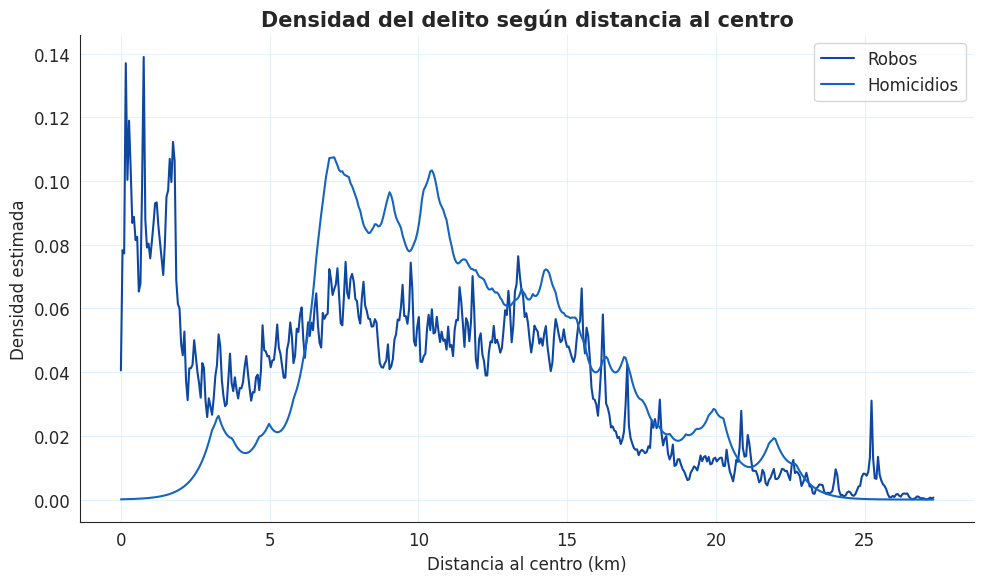

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    malla_dist.ravel(),
    dens_robo,
    label="Robos"
)

plt.plot(
    malla_dist.ravel(),
    dens_hom,
    label="Homicidios"
)

plt.title("Densidad del delito según distancia al centro")
plt.xlabel("Distancia al centro (km)")
plt.ylabel("Densidad estimada")
plt.legend()

plt.tight_layout()
plt.show()

4.5 Identificar la distancia de máxima densidad

In [ ]:
pico_robo = malla_dist[np.argmax(dens_robo)][0]
pico_hom = malla_dist[np.argmax(dens_hom)][0]

print(f"Mayor densidad de robos alrededor de: {pico_robo:.2f} km del centro")
print(f"Mayor densidad de homicidios alrededor de: {pico_hom:.2f} km del centro")

Mayor densidad de robos alrededor de: 0.77 km del centro
Mayor densidad de homicidios alrededor de: 7.17 km del centro


### Interpretación del gradiente de densidad

Los resultados muestran que los robos y los homicidios no se concentran de la misma forma con respecto al centro de la ciudad.

En los robos, la mayor densidad aparece muy cerca del centro, alrededor de 0,77 km, mientras que en los homicidios el punto de mayor densidad se encuentra más alejado, aproximadamente a 7,17 km.

También se observa una diferencia importante en los anchos de banda seleccionados por validación cruzada. Para robos se obtiene un valor de 0,05 km, lo que genera una curva mucho más irregular y sensible a cambios locales. En homicidios, el ancho de banda es mayor 0,564 km, por lo que la curva es más suave.

En conjunto, esto muestra que ambos delitos tienen patrones espaciales diferentes y que no tendría sentido asumir que se comportan igual respecto al centro de la ciudad.

Representar el delito únicamente a partir de la distancia al centro ayuda a resumir el patrón espacial, pero también simplifica bastante el problema.

Dos lugares pueden estar a la misma distancia del centro y encontrarse en zonas completamente distintas de la ciudad, por lo que este enfoque no permite identificar con precisión dónde debería concentrarse el patrullaje.

Por esta razón, este análisis es útil para entender el gradiente general del delito, pero no sería suficiente por sí solo para tomar una decisión operativa de patrullaje.

## Paso 5. Puntos calientes en el plano

In [ ]:
lat0 = 41.85
R_TIERRA = 6371.0088

def proyectar_km(lon, lat):
    x = np.radians(lon) * R_TIERRA * np.cos(np.radians(lat0))
    y = np.radians(lat) * R_TIERRA
    return np.column_stack([x, y])

xy_robo = proyectar_km(crimenes.loc[crimenes["tipo_crimen"] == "robo", "lon"].values,
                       crimenes.loc[crimenes["tipo_crimen"] == "robo", "lat"].values)
xy_hom = proyectar_km(crimenes.loc[crimenes["tipo_crimen"] == "homicidio", "lon"].values,
                      crimenes.loc[crimenes["tipo_crimen"] == "homicidio", "lat"].values)

kde_robo_ref = KDEMultivariate(data=xy_robo, var_type="cc", bw="normal_reference")
kde_hom_ref = KDEMultivariate(data=xy_hom, var_type="cc", bw="normal_reference")
print("normal_reference — robos (km):", kde_robo_ref.bw)
print("normal_reference — homicidios (km):", kde_hom_ref.bw)

normal_reference — robos (km): [0.94524989 1.89045588]
normal_reference — homicidios (km): [2.32715605 3.7426145 ]


/usr/local/lib/python3.13/dist-packages/pandas/util/_decorators.py:213: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


In [ ]:
# cv_ml es costoso en n grande
rng = np.random.RandomState(RANDOM_STATE)
idx_sub = rng.choice(len(xy_robo), size=800, replace=False)
kde_robo_cv = KDEMultivariate(data=xy_robo[idx_sub], var_type="cc", bw="cv_ml")
kde_hom_cv = KDEMultivariate(data=xy_hom, var_type="cc", bw="cv_ml")
print("cv_ml — robos, submuestra n=800 (km):", kde_robo_cv.bw)
print("cv_ml — homicidios, n=144 (km):", kde_hom_cv.bw)
print()
print("Razón cv_ml / normal_reference — robos:", kde_robo_cv.bw / kde_robo_ref.bw)
print("Razón cv_ml / normal_reference — homicidios:", kde_hom_cv.bw / kde_hom_ref.bw)

/usr/local/lib/python3.13/dist-packages/statsmodels/nonparametric/kernel_density.py:221: RuntimeWarning: invalid value encountered in log
  L += func(f_i)
/usr/local/lib/python3.13/dist-packages/statsmodels/nonparametric/kernel_density.py:221: RuntimeWarning: divide by zero encountered in log
  L += func(f_i)


cv_ml — robos, submuestra n=800 (km): [0.42732477 0.98745709]
cv_ml — homicidios, n=144 (km): [0.8721025  1.56220012]

Razón cv_ml / normal_reference — robos: [0.45207597 0.52233808]
Razón cv_ml / normal_reference — homicidios: [0.37475033 0.41740877]


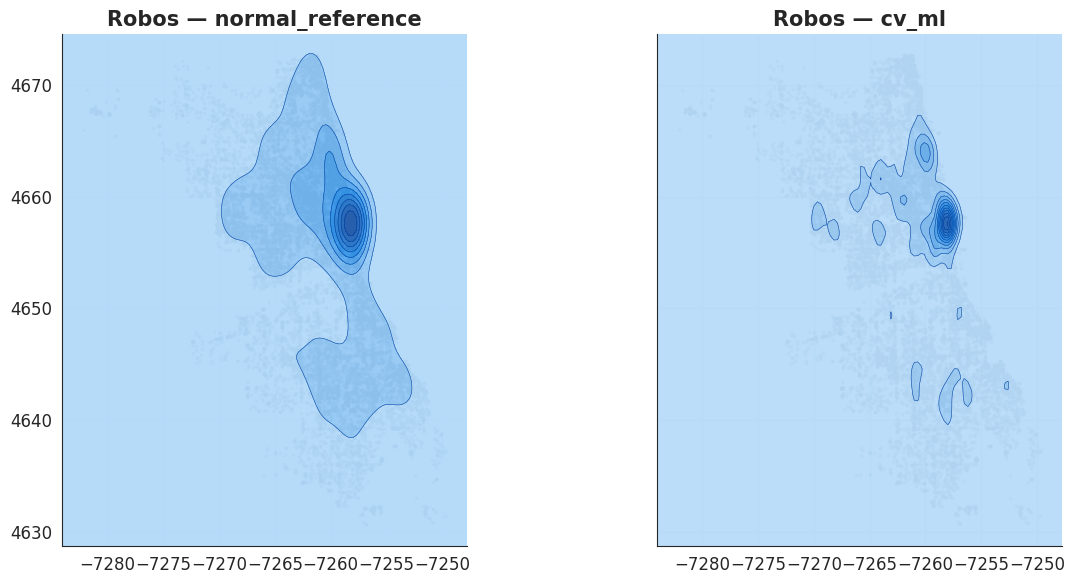

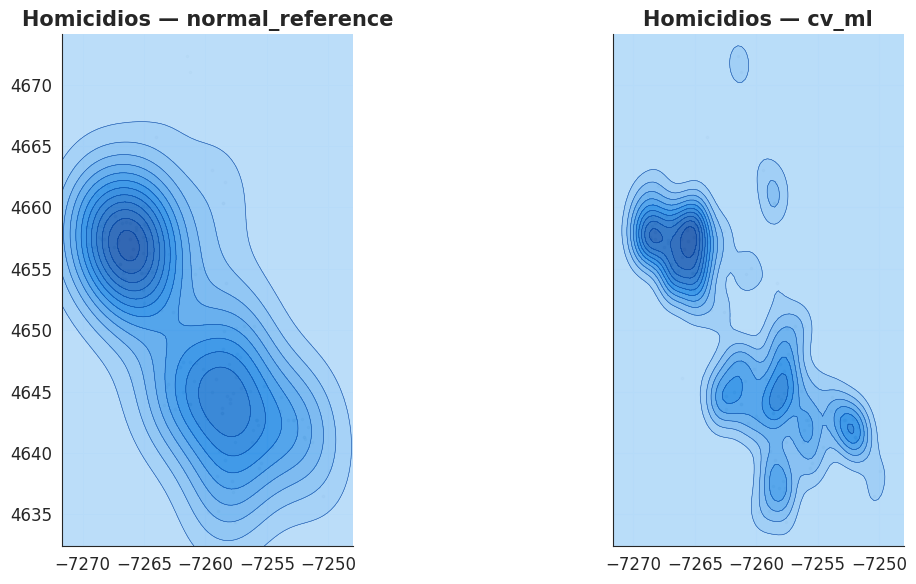

In [ ]:
def malla_evaluacion(xy, paso_km=0.3, margen_km=2):
    xmin, ymin = xy.min(axis=0) - margen_km
    xmax, ymax = xy.max(axis=0) + margen_km
    xs = np.arange(xmin, xmax, paso_km)
    ys = np.arange(ymin, ymax, paso_km)
    gx, gy = np.meshgrid(xs, ys)
    return gx, gy, np.column_stack([gx.ravel(), gy.ravel()])

def graficar_contornos(xy, kde_ref, kde_cv, titulo):
    gx, gy, malla = malla_evaluacion(xy)
    dens_ref = kde_ref.pdf(malla).reshape(gx.shape)
    dens_cv = kde_cv.pdf(malla).reshape(gx.shape)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
    for ax, dens, sub in zip(axes, [dens_ref, dens_cv], ["normal_reference", "cv_ml"]):
        ax.scatter(xy[:, 0], xy[:, 1], s=3, color="#B0BEC5", alpha=0.3)
        cs = ax.contourf(gx, gy, dens, levels=12, cmap=CMAP_AZUL, alpha=0.85)
        ax.contour(gx, gy, dens, levels=12, colors=AZUL_OSCURO, linewidths=0.4)
        ax.set_title(f"{titulo} — {sub}")
        ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

graficar_contornos(xy_robo, kde_robo_ref, kde_robo_cv, "Robos")
graficar_contornos(xy_hom, kde_hom_ref, kde_hom_cv, "Homicidios")

### Comparación de los puntos calientes

Los dos métodos identifican concentraciones espaciales del delito, pero el nivel de detalle cambia de manera importante según el ancho de banda utilizado.

normal_reference selecciona anchos de banda mayores tanto para robos como para homicidios, por lo que genera superficies más suaves y puntos calientes más amplios. En cambio, cv_ml utiliza valores menores y permite observar concentraciones más localizadas.

La diferencia es especialmente clara en homicidios, donde cv_ml reduce considerablemente el ancho de banda frente a normal_reference. Esto muestra que la identificación de un punto caliente depende en buena medida del nivel de suavizamiento elegido.

Para una decisión de patrullaje, un mapa más detallado no necesariamente implica una mejor decisión.

Un ancho de banda pequeño permite identificar zonas muy específicas, pero también puede hacer que el resultado sea más sensible a variaciones locales. Por el contrario, un mayor suavizamiento ayuda a identificar zonas generales de concentración, aunque puede ocultar focos más pequeños.

Por esta razón, los puntos calientes deberían utilizarse como una herramienta para priorizar zonas y no como una instrucción automática de patrullaje.

La superficie de densidad por sí sola no define exactamente dónde debe patrullarse. Para convertirla en una decisión operativa sería necesario establecer un criterio adicional, por ejemplo seleccionar las zonas con mayor densidad estimada o definir un umbral a partir del cual una zona sea considerada prioritaria.

Esta decisión debe combinarse con información operativa adicional, como disponibilidad de recursos, horarios, accesibilidad y conocimiento local de la policía.

## Paso 6. ¿Qué explica la ubicación de los puntos calientes?

In [ ]:
import osmnx as ox
import time

ox.settings.use_cache = True
ox.settings.timeout = 300

tags_comerciales = {"landuse": ["commercial", "retail"], "shop": True}

try:
    contorno_ciudad = areas.union_all()
except AttributeError:
    contorno_ciudad = areas.unary_union

contorno_consulta = contorno_ciudad.convex_hull

feats = None
n_intentos = 4
espera_seg = 20
for intento in range(1, n_intentos + 1):
    try:
        print(f"Intento {intento}/{n_intentos}...")
        feats = ox.features_from_polygon(contorno_consulta, tags=tags_comerciales)
        print(f"¡Consulta exitosa! {len(feats)} elementos.")
        break
    except Exception as e:
        print(f"  falló: {type(e).__name__}: {e}")
        if intento < n_intentos:
            print(f"  esperando {espera_seg}s antes de reintentar...")
            time.sleep(espera_seg)

if feats is None:
    raise RuntimeError(
        "El servidor de OpenStreetMap (Overpass) no respondió tras varios intentos. "
        "Es un problema del servicio externo, no del código: esperen unos minutos y "
        "vuelvan a correr esta celda."
    )

feats = feats[["geometry"]].copy()
feats["geometry"] = feats["geometry"].apply(lambda g: g if g.geom_type == "Point" else g.centroid)
feats = gpd.GeoDataFrame(feats, geometry="geometry", crs=areas.crs)

feats_area = gpd.sjoin(feats, areas[["area_numbe", "geometry"]], how="inner", predicate="within")
conteo_comercial = feats_area.groupby("area_numbe").size()
print(f"Elementos comerciales dentro de las 77 áreas: {feats_area.shape[0]} de {len(feats)} encontrados")

resumen_area["n_comercios_osm"] = resumen_area["area_numbe"].map(conteo_comercial).fillna(0).astype(int)
resumen_area["comercios_por_km2"] = resumen_area["n_comercios_osm"] / resumen_area["area_km2"]
resumen_area["robo_por_km2"] = resumen_area["robo"] / resumen_area["area_km2"]
resumen_area["homicidio_por_km2"] = resumen_area["homicidio"] / resumen_area["area_km2"]

for col in ["robo", "homicidio", "robo_por_km2", "homicidio_por_km2", "delitos_por_km2"]:
    r, p = stats.pearsonr(resumen_area["n_comercios_osm"], resumen_area[col])
    print(f"corr(n_comercios_osm, {col}) = {r:.3f}  (p={p:.4g})")

Intento 1/4...
  falló: ReadTimeout: HTTPSConnectionPool(host='overpass.private.coffee', port=443): Read timed out. (read timeout=180)
  esperando 20s antes de reintentar...
Intento 2/4...
¡Consulta exitosa! 12404 elementos.
Elementos comerciales dentro de las 77 áreas: 9843 de 12404 encontrados
corr(n_comercios_osm, robo) = 0.791  (p=1.14e-17)
corr(n_comercios_osm, homicidio) = -0.083  (p=0.4727)
corr(n_comercios_osm, robo_por_km2) = 0.571  (p=5.777e-08)
corr(n_comercios_osm, homicidio_por_km2) = -0.187  (p=0.104)
corr(n_comercios_osm, delitos_por_km2) = 0.570  (p=6.396e-08)


## Paso 7. Ranking de procedimientos, transferencia y recomendación

### 7.1 Criterios para comparar los procedimientos

Para comparar los procedimientos se utilizan criterios relacionados directamente con la decisión de patrullaje.

Los criterios seleccionados son:

- **Utilidad operativa:** qué tan fácil es pasar del resultado del método a una decisión concreta de dónde patrullar.
- **Resolución espacial:** qué tan específica es la localización de las zonas prioritarias.
- **Estabilidad:** qué tanto cambia el resultado frente a decisiones metodológicas como el nivel de suavizamiento.
- **Interpretabilidad:** qué tan fácil es explicar el resultado a un tomador de decisiones.
- **Requerimientos de datos:** qué tan complejo es implementar y mantener el procedimiento.

In [ ]:
ranking_preliminar = pd.DataFrame({
    "Procedimiento": [
        "Conteo por área",
        "Conteo por superficie",
        "Distancia al centro",
        "KDE bivariado - normal_reference",
        "KDE bivariado - cv_ml"
    ],
    "Utilidad operativa": [
        "Alta",
        "Alta",
        "Baja",
        "Media",
        "Alta"
    ],
    "Resolución espacial": [
        "Baja",
        "Baja",
        "Muy baja",
        "Media",
        "Alta"
    ],
    "Estabilidad": [
        "Alta",
        "Alta",
        "Media",
        "Alta",
        "Media"
    ],
    "Interpretabilidad": [
        "Alta",
        "Alta",
        "Alta",
        "Media",
        "Media"
    ],
    "Requerimientos de datos": [
        "Bajos",
        "Medios",
        "Bajos",
        "Medios",
        "Medios"
    ]
})

ranking_preliminar

,Procedimiento,Utilidad operativa,Resolución espacial,Estabilidad,Interpretabilidad,Requerimientos de datos
0,Conteo por área,Alta,Baja,Alta,Alta,Bajos
1,Conteo por superficie,Alta,Baja,Alta,Alta,Medios
2,Distancia al centro,Baja,Muy baja,Media,Alta,Bajos
3,KDE bivariado - normal_reference,Media,Media,Alta,Media,Medios
4,KDE bivariado - cv_ml,Alta,Alta,Media,Media,Medios


Los procedimientos más simples, como el conteo por área o por superficie, son fáciles de interpretar y aplicar, pero su principal limitación es que dependen de unidades administrativas y tienen poca resolución espacial.

El análisis por distancia al centro permite resumir el gradiente urbano del delito, pero pierde demasiada información sobre la ubicación concreta de las concentraciones y por sí solo tiene poca utilidad para decidir dónde patrullar.

Los KDE bivariados permiten identificar puntos calientes de manera continua y con mayor detalle espacial. normal_reference produce superficies más suaves y estables, mientras que cv_ml identifica concentraciones más localizadas, aunque también es más sensible al ancho de banda seleccionado.

In [ ]:
ranking_final_preliminar = pd.DataFrame({
    "Posición": [1, 2, 3, 4, 5],
    "Procedimiento": [
        "KDE bivariado - cv_ml",
        "KDE bivariado - normal_reference",
        "Conteo por superficie",
        "Conteo por área",
        "Distancia al centro"
    ]
})

ranking_final_preliminar

,Posición,Procedimiento
0,1,KDE bivariado - cv_ml
1,2,KDE bivariado - normal_reference
2,3,Conteo por superficie
3,4,Conteo por área
4,5,Distancia al centro


### Ranking preliminar

De manera preliminar, el procedimiento mejor posicionado es el KDE bivariado con cv_ml, porque ofrece la mayor resolución espacial y permite identificar concentraciones concretas del delito, algo especialmente útil para una decisión de patrullaje.

El KDE con normal_reference ocupa una segunda posición porque genera una representación más suavizada y estable, aunque puede ocultar focos pequeños.

Los métodos basados en áreas comunitarias son más simples e interpretables, pero dependen de los límites administrativos y no permiten localizar con precisión los puntos calientes dentro de cada área.

Finalmente, el análisis por distancia al centro es útil para describir el patrón general del delito, pero pierde demasiada información espacial para utilizarlo como herramienta principal de focalización.

### Recomendación preliminar

Con la evidencia disponible hasta este punto, se recomienda utilizar un KDE bivariado como herramienta principal para identificar zonas prioritarias de patrullaje.

Entre las alternativas evaluadas, cv_ml ofrece una mayor capacidad para localizar concentraciones específicas del delito. Sin embargo, su mayor nivel de detalle también implica una mayor sensibilidad a las decisiones de suavizamiento, por lo que sería recomendable contrastar sus resultados con una alternativa más estable como normal_reference.

La focalización no debería utilizarse de manera automática. Los mapas de densidad deben funcionar como una herramienta de priorización y complementarse con información operativa, conocimiento local y controles que eviten interpretar las concentraciones observadas como relaciones causales.

La versión final de esta recomendación se complementará con los resultados del análisis de uso comercial del suelo del Paso 6.